In [1]:
from keras.layers import Input, Conv2D, BatchNormalization, ReLU, MaxPooling2D, Concatenate, GlobalMaxPooling2D, Dropout, Dense, Lambda, Reshape, Activation, Multiply, Add
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, TensorBoard
from keras.layers import Input, Dropout, Dense, GlobalAveragePooling2D
from keras.applications import VGG16, DenseNet121, InceptionV3, VGG19, Xception
from keras.models import Sequential, Model
from keras import backend as K
from tensorflow import keras
import tensorflow as tf
import numpy as np
import sys
from tool import load_data, draw_curve, draw_matrix, TimeHistory

2024-10-14 14:15:36.134839: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


100%|██████████| 1000/1000 [00:05<00:00, 179.82it/s]


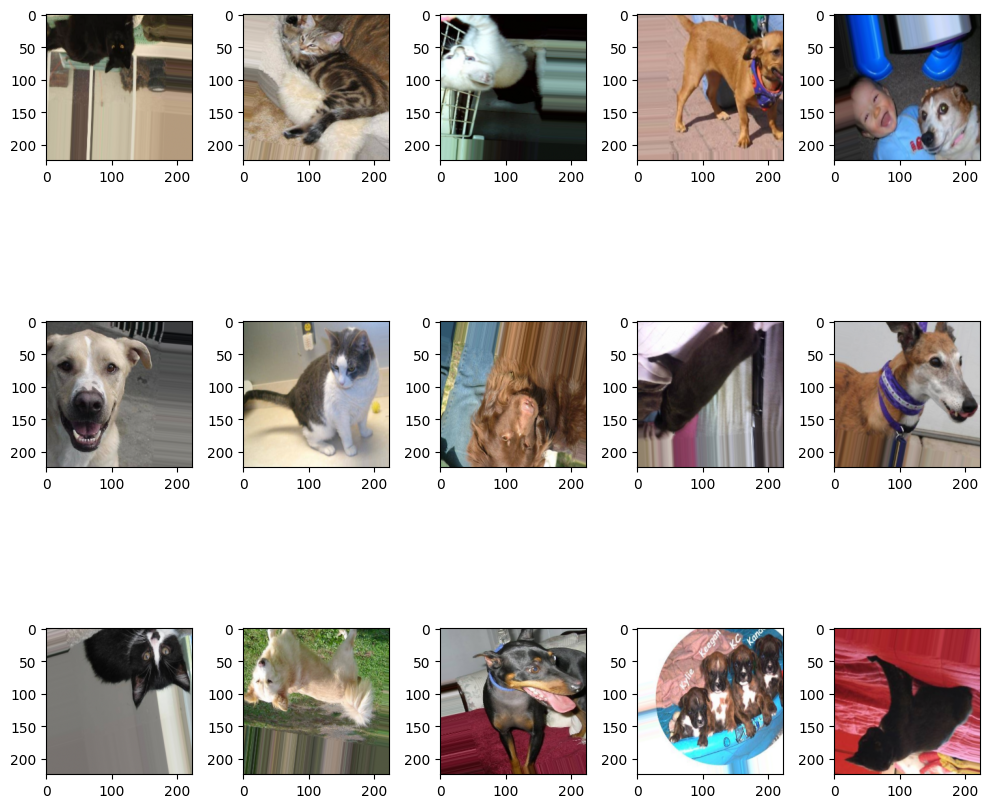

(2000, 224, 224, 3)
(8000, 224, 224, 3)
(2000, 2)
(8000, 2)


In [2]:
labels = ['dog', 'cat']
data_path = '/root/autodl-tmp/datasets/augmented'
image_size = 224
x_train, x_test, y_train, y_test = load_data(data_path, labels, image_size)

In [3]:
from tensorflow.keras.layers import Add
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    ReLU,
    MaxPooling2D,
    Concatenate,
    GlobalMaxPooling2D,
    Dropout,
    Dense,
    Lambda,
    Reshape,
    Activation,
    Multiply,
    Add
)
from tensorflow.keras.models import Model
from tensorflow.keras import backend as K

def block(inputs, filters):
    a = Conv2D(filters, 3, padding='same')(inputs)
    a = BatchNormalization()(a)
    a = ReLU()(a)
    
    b = Conv2D(filters, 3, padding='same')(a)
    b = BatchNormalization()(b)
    b = ReLU()(b)
    
    c = Conv2D(filters, 3, padding='same')(b)
    c = BatchNormalization()(c)
    c = ReLU()(c)
    
    d = Conv2D(filters, 3, padding='same')(c)
    d = BatchNormalization()(d)
    d = ReLU()(d)
    
    mid = Concatenate()([a, b, c, d])
    mid = Conv2D(2 * filters, 1, padding='same')(mid)
    mid = BatchNormalization()(mid)
    mid = ReLU()(mid)
    
    x = Conv2D(filters * 2, 1)(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    
    x = Add()([mid, x])
    
    y = Conv2D(filters * 2, 1)(x)
    y = BatchNormalization()(y)
    y = ReLU()(y)
    
    return y

def Global_attention_block(C_A):
    x = Lambda(lambda x: K.mean(x, axis=-1, keepdims=True))(C_A)
    y = Lambda(lambda x: K.max(x, axis=-1, keepdims=True))(C_A)
    
    x = Concatenate()([x, y])
    x = Activation('relu')(x)
    x = Conv2D(1, 1, padding='same')(x)
    x = Activation('sigmoid')(x)
    S_A = Multiply()([x, C_A])
    
    return S_A

def self_attention(inp):
    shp = inp.shape
    a = Conv2D(shp[3] // 8, 1, padding='same')(inp)
    a = Activation('relu')(a)
    
    b = Conv2D(shp[3] // 8, 1, padding='same')(inp)
    b = Activation('relu')(b)
    
    c = Conv2D(shp[3] // 8, 1, padding='same')(inp)
    c = Activation('relu')(c)
    
    a = Reshape((shp[1] * shp[2], shp[3] // 8))(a)
    b = Reshape((shp[1] * shp[2], shp[3] // 8))(b)
    b = K.permute_dimensions(b, (0, 2, 1))
    c = Reshape((shp[1] * shp[2], shp[3] // 8))(c)
    inter = K.batch_dot(a, b)
    inter = Activation('softmax')(inter)
    out = K.batch_dot(inter, c)
    out = Reshape((shp[1], shp[2], shp[3] // 8))(out)
    out = Conv2D(shp[3], 1, padding='same')(out)
    out = Activation('relu')(out)
    
    return out

def channel_attention(inputs):
    shape = K.int_shape(inputs)
    x = MaxPooling2D(pool_size=(shape[1], shape[2]))(inputs)
    x = Conv2D(shape[3] // 8, 1, padding='same', kernel_initializer='he_normal', use_bias=False)(x)
    x = Activation('relu')(x)
    x = Conv2D(shape[3], 1, padding='same', kernel_initializer='he_normal', use_bias=False)(x)
    x = Activation('sigmoid')(x)
    x = Multiply()([x, inputs])
    
    return x

def load_model():
    K.clear_session()
    inputs = Input(shape=(224, 224, 3))
    x = Conv2D(16, 3, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D()(x)
    
    x = Conv2D(16, 3, padding='same')(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling2D()(x)
    
    a1 = block(x, 32)
    x = MaxPooling2D()(a1)
    
    a2 = block(x, 64)
    x = MaxPooling2D()(a2)
    
    a3 = block(x, 128)
    a31 = self_attention(a3)
    a32 = Global_attention_block(a3)
    a3 = Add()([a31, a32])
    x = channel_attention(a3)
    
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.5)(x)
    x = Dense(2, activation='softmax')(x)
    model = Model(inputs=inputs, outputs=x)
    
    return model

In [4]:
model = load_model()
adam = keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

2024-10-14 14:16:47.126926: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2024-10-14 14:16:47.592781: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22167 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090 D, pci bus id: 0000:5a:00.0, compute capability: 8.9


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 224, 224, 16  448         ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 batch_normalization (BatchNorm  (None, 224, 224, 16  64         ['conv2d[0][0]']                 
 alization)                     )                                                             

In [5]:
tensorboard = TensorBoard(log_dir = 'logs')
Checkpoint = ModelCheckpoint(filepath='model-ARM-Net.h5',
                             monitor='val_accuracy', verbose=1, save_best_only=False, mode='min')
reduce_lr = ReduceLROnPlateau(monitor = 'val_accuracy', factor = 0.3, patience = 5, min_delta = 0.001,
                              mode='auto',verbose=1)
time_callback = TimeHistory()
history = model.fit(x_train,y_train,validation_split=0.1, epochs =20, verbose=1, batch_size=36,
                   callbacks=[tensorboard,Checkpoint,reduce_lr, time_callback])

Epoch 1/20


2024-10-14 14:17:05.163163: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8101
2024-10-14 14:17:06.112962: W tensorflow/stream_executor/gpu/asm_compiler.cc:230] Falling back to the CUDA driver for PTX compilation; ptxas does not support CC 8.9
2024-10-14 14:17:06.112985: W tensorflow/stream_executor/gpu/asm_compiler.cc:233] Used ptxas at ptxas
2024-10-14 14:17:06.113055: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] UNIMPLEMENTED: ptxas ptxas too old. Falling back to the driver to compile.
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2024-10-14 14:17:07.020753: I tensorflow/stream_executor/cuda/cuda_blas.cc:1786] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.


200/200 [==============================] - ETA: 0s - loss: 0.6797 - accuracy: 0.5910
Epoch 1: saving model to model-ARM-Net.h5
Epoch 1: 22.84 seconds
200/200 [==============================] - 23s 56ms/step - loss: 0.6797 - accuracy: 0.5910 - val_loss: 0.8786 - val_accuracy: 0.4812 - lr: 1.0000e-04
Epoch 2/20
200/200 [==============================] - ETA: 0s - loss: 0.6380 - accuracy: 0.6313
Epoch 2: saving model to model-ARM-Net.h5
Epoch 2: 7.16 seconds
200/200 [==============================] - 7s 36ms/step - loss: 0.6380 - accuracy: 0.6313 - val_loss: 0.7549 - val_accuracy: 0.5312 - lr: 1.0000e-04
Epoch 3/20
199/200 [============================>.] - ETA: 0s - loss: 0.5875 - accuracy: 0.6817
Epoch 3: saving model to model-ARM-Net.h5
Epoch 3: 7.14 seconds
200/200 [==============================] - 7s 36ms/step - loss: 0.5875 - accuracy: 0.6821 - val_loss: 0.5524 - val_accuracy: 0.7337 - lr: 1.0000e-04
Epoch 4/20
199/200 [============================>.] - ETA: 0s - loss: 0.5439 - acc

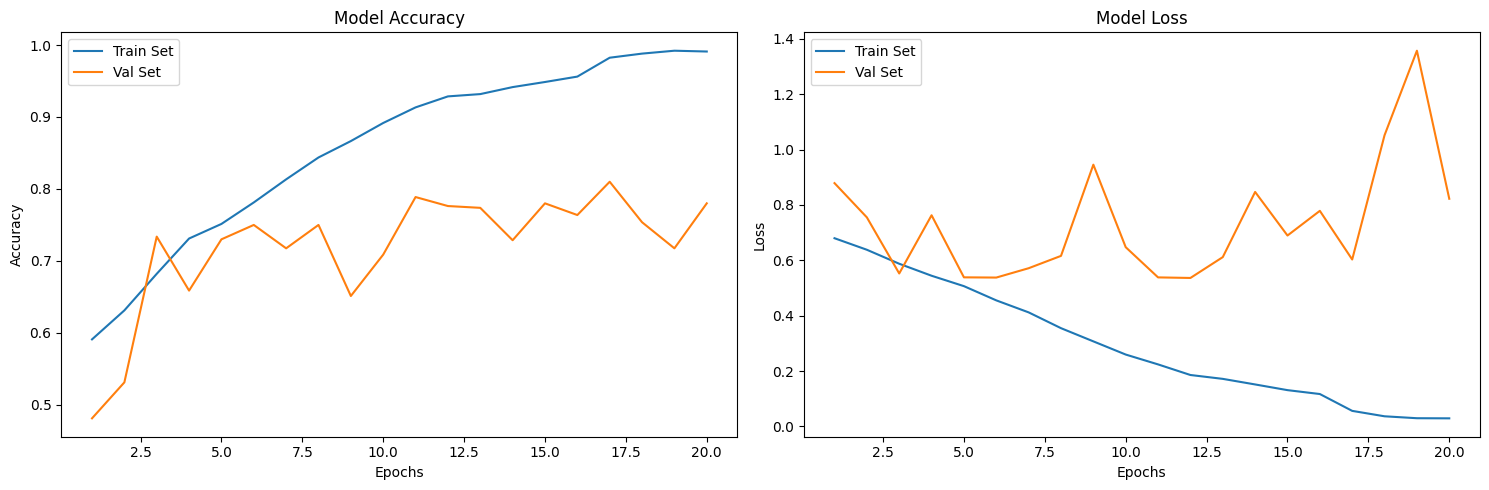

In [6]:
draw_curve(history)

63/63 [==============================] - 1s 13ms/step - loss: 1.2410 - accuracy: 0.7200
Test Accuracy:  72.0
              precision    recall  f1-score   support

         dog     0.7455    0.6680    0.7046      1000
         cat     0.6993    0.7720    0.7338      1000

    accuracy                         0.7200      2000
   macro avg     0.7224    0.7200    0.7192      2000
weighted avg     0.7224    0.7200    0.7192      2000



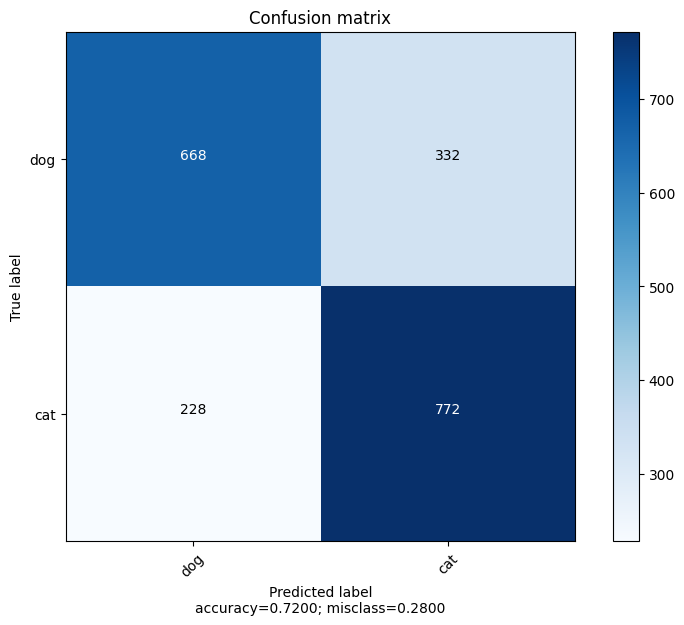

In [7]:
pred = model.predict(x_test)
pred = np.argmax(pred,axis=1)
y_test_new = np.argmax(y_test,axis=1)
loss,acc = model.evaluate(x_test,y_test,verbose = 1)
draw_matrix(labels, y_test_new, pred, acc)